# 06 · Prediction Plots — Ungauged / Specialized vs HBV

Interactive plotting notebook to visualise TFT streamflow predictions against observations and the HBV benchmark, for any station.

Choose in **Section 3**:
- **Experiment**: `ungauged` or `specialized`
- **Station**: SNIRH code (e.g. `03J_01H`)
- **Version** (specialization only): defaults to `version_0`, changeable
- **Date window**: start and end for the plot

The figure uses the four-panel layout (`Training/Validation/Test` band, temperature, precipitation, forecast) produced by the `plot_prediction` function, with the HBV simulation overlaid on the forecast panel.

### Inputs
| Path | Content |
|---|---|
| `results/tft/predictions/ungauged/config_*/<STATION>.csv` | TFT ungauged predictions |
| `results/tft/predictions/specialization/config_*/<STATION>/version_*/<STATION>.csv` | TFT specialization predictions |
| `results/hbv prediction/<STATION>/<STATION>_HBV_simulation.csv` | HBV simulation |
| `data/meteorological/<STATION>.csv` | ERA5-Land tp, t2m |
| `data/geomorphological/catchment_descriptors.csv` | Catchment area |

> The prediction CSVs are those produced by `collect_predictions_ungauged.py` and `collect_predictions_specialization.py`: columns `observed`, `split`, and `p_0.01 … p_0.99` at leadtime = 3 days.

## 0 · Imports and paths

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ── Paths ──────────────────────────────────────────────────────────────────────
ROOT       = Path("..")
PRED_UNG   = ROOT / "results" / "tft" / "prediction" / "ungauged"
PRED_SPE   = ROOT / "results" / "tft" / "prediction" / "specialization"
HBV_DIR    = ROOT / "results" / "hbv" / "prediction"
METEO_DIR  = ROOT / "data" / "meteorological"
GEO_FILE   = ROOT / "data" / "geomorphological" / "catchment_descriptors.csv"
OUT_DIR    = ROOT / "results" / "comparison_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Catchment descriptors (for area) ────────────────────────────────────────────
desc = pd.read_csv(GEO_FILE, sep=";")
desc["station"] = desc["Group"].str.replace("/", "_", regex=False)
desc = desc.set_index("station")

# Quantile levels present in the prediction CSVs
QUANTILES = [0.01, 0.05, 0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9, 0.95, 0.99]
LEAD      = pd.Timedelta("3D")   # all prediction CSVs are leadtime = 3 days

print("Ready.")

Ready.


## 1 · `plot_prediction` — the formatting/plotting function

Adapted from the author's plotting utility. It reconstructs the multi-level column layout expected internally from a flat prediction CSV, then draws the four-panel figure.

In [5]:
def cm2inch(*tupl):
    inch = 2.54
    if isinstance(tupl[0], tuple):
        return tuple(i / inch for i in tupl[0])
    return tuple(i / inch for i in tupl)


def plot_prediction(prediction, data, group, lead, temperature, precipitation,
                    target_label="Target", plot_persistence=False,
                    add_markers=False, partial_retraining=False):
    """
    Four-panel prediction plot: split band, temperature, precipitation, forecast.

    Parameters
    ----------
    prediction : DataFrame
        Multi-index columns (Group, Type, Leadtime, Probability).
    data : DataFrame
        Meteorological data with a 'Group' column plus temperature/precipitation columns.
    group : str
        SNIRH station code (e.g. '03J/01H').
    lead : pd.Timedelta
        Forecast lead time to plot (here always 3 days).
    temperature, precipitation : str
        Column names in `data`.
    """
    prediction_ = prediction.loc[:, group]
    prediction_freq = pd.infer_freq(prediction_.index[:5])
    prediction_ = prediction_.reindex(
        pd.date_range(start=prediction_.index[0], end=prediction_.index[-1],
                      freq=prediction_freq)
    )

    color_observed = "darkturquoise"
    color_median   = "crimson"

    pred     = prediction_.loc[:, (slice(None), lead)]
    observed = prediction_.loc[:, ["Observed"]]

    try:
        training = prediction_.loc[:, ["Training"]]
    except Exception:
        training = pd.DataFrame(np.zeros((observed.shape[0], 1), bool), index=prediction_.index)
    try:
        validation = prediction_.loc[:, ["Validation"]]
    except Exception:
        validation = pd.DataFrame(np.zeros((observed.shape[0], 1), bool), index=prediction_.index)
    try:
        test = prediction_.loc[:, ["Test"]]
    except Exception:
        test = pd.DataFrame(np.ones((observed.shape[0], 1), bool), index=prediction_.index)

    quantiles = pred.columns.get_level_values("Probability").unique()
    missing   = prediction_.loc[:, ["Observed"]].isna()

    data_ = data.loc[(data.loc[:, "Group"] == group).values.ravel(), :]
    data_ = data_.reindex(prediction_.index)

    fig, (ax_training, ax_temperature, ax_precipitation, ax_forecast) = plt.subplots(
        4, 1, gridspec_kw={"height_ratios": [0.15, 1, 1, 2]},
        constrained_layout=True, sharex=True, figsize=cm2inch(40, 30)
    )

    # ── Forecast panel ───────────────────────────────────────────────────────────
    legendSamples, legendLabels = [], []
    if len(quantiles) > 1:
        color_len = len(quantiles) // 2
        coverage = np.array([j - i for i, j in
                             zip(quantiles[:color_len], quantiles[::-1][:color_len])])
        coverage -= coverage.min()
        coverage += 0.05 * coverage.max()
        coverage /= coverage.max()
        colors = np.repeat(np.expand_dims(coverage, 1), 3, axis=1)

        i0 = 0
        for i0 in np.arange(0, len(quantiles) // 2):
            tmp = pred.iloc[:, [i0, len(quantiles) - 1 - i0]]
            ax_forecast.fill_between(pred.index, tmp.iloc[:, 0], tmp.iloc[:, -1],
                                     facecolor=colors[i0, ], linewidth=0, alpha=1, zorder=i0)
            legendSamples.append(plt.Rectangle((0, 0), 1, 1, fc=colors[i0, ], linewidth=0))
            q_ = tmp.columns.get_level_values("Probability")
            legendLabels.append("{f:03.1f}-{t:03.1f}%".format(f=q_[0] * 100, t=q_[-1] * 100))

        center = quantiles[len(quantiles) // 2]
        ax_forecast.plot(pred.loc[:, (slice(None), slice(None), center)],
                         linestyle="--", color=color_median, zorder=i0 + 1)
        ax_forecast.plot(pred.iloc[:, 0],  linestyle=":", color=[0.85] * 3)
        ax_forecast.plot(pred.iloc[:, -1], linestyle=":", color=[0.85] * 3)

        legendSamples.append(Line2D([0], [0], color=color_median, linestyle="--"))
        legendLabels.append("Median prediction")
    else:
        style = dict(linestyle="-", color=color_median, zorder=1)
        if add_markers:
            style.update(marker="o", markersize=3)
        ax_forecast.plot(pred.loc[:, pred.columns.get_level_values("Type") != "Observed"], **style)
        legendSamples.append(Line2D([0], [0], color=color_median, linestyle="-"))
        legendLabels.append("Prediction")

    obs_series = observed.iloc[:, 0]
    ax_forecast.plot(obs_series.index, obs_series.values,
                     color=color_observed, zorder=pred.shape[1] // 2, alpha=0.75)
    legendSamples.append(Line2D([0], [0], color=color_observed, linestyle="-"))
    legendLabels.append("Observed")

    if plot_persistence:
        persistence = observed.copy()
        persistence.index += lead
        ax_forecast.plot(persistence, linestyle="-.", color=color_observed,
                         zorder=pred.shape[1] // 2, alpha=0.25)
        legendSamples.append(Line2D([0], [0], color=color_observed, linestyle="-.", alpha=0.25))
        legendLabels.append("Persistence")

    ax_forecast.legend(legendSamples, legendLabels, fontsize=10, numpoints=1, loc=2, frameon=False)
    ax_forecast.set_ylabel(target_label)
    ax_forecast.grid(True)

    # Save the forecast-panel legend entries so the caller can extend them
    forecast_legend = (list(legendSamples), list(legendLabels))

    # ── Precipitation panel ────────────────────────────────────────────────────────
    ax_precipitation.plot(data_.index, data_.loc[:, precipitation], color="k")
    ax_precipitation.set_ylabel("Precipitation [mm]")
    ax_precipitation.grid(True)
    ax_precipitation.invert_yaxis()
    ax_precipitation.legend([Line2D([0], [0], color="k")], ["Precipitation"], frameon=False)

    # ── Temperature panel ──────────────────────────────────────────────────────────
    ax_temperature.plot(data_.index, data_.loc[:, temperature], color="r", zorder=2)
    ax_temperature.set_ylabel("Temperature [C]")
    ax_temperature.grid(True)
    ax_temperature.yaxis.label.set_color("r")
    ax_temperature.legend([Line2D([0], [0], color="r")], ["Temperature"], frameon=False)

    # ── Split band panel ───────────────────────────────────────────────────────────
    training_mask   = training.values.ravel().astype(bool)
    validation_mask = validation.values.ravel().astype(bool)
    test_mask       = test.values.ravel().astype(bool)
    no_input_mask   = missing.values.ravel().astype(bool)

    tr = ax_training.get_xaxis_transform()
    ax_training.fill_between(pred.index, 0, 1, where=training_mask,   transform=tr, color="snow")
    ax_training.fill_between(pred.index, 0, 1, where=validation_mask, transform=tr, color="steelblue")
    ax_training.fill_between(pred.index, 0, 1, where=test_mask,       transform=tr, color="darkslategray")
    ax_training.fill_between(pred.index, 0, 1, where=no_input_mask,   transform=tr, color="lightcoral")

    legendSamples = [plt.Rectangle((0, 0), 1, 1, fc="snow",          ec="k", linewidth=1),
                     plt.Rectangle((0, 0), 1, 1, fc="steelblue",     ec="k", linewidth=1),
                     plt.Rectangle((0, 0), 1, 1, fc="darkslategray", ec="k", linewidth=1),
                     plt.Rectangle((0, 0), 1, 1, fc="lightcoral",    ec="k", linewidth=1)]
    legendLabels = ["Training", "Validation", "Test", "Missing"]

    if partial_retraining:
        unassigned = ~(training_mask | validation_mask | test_mask)
        ax_training.fill_between(pred.index, 0, 1, where=unassigned, transform=tr,
                                 facecolor="w", hatch="//", edgecolor="darkgray", linewidth=0.5)
        legendSamples.append(plt.Rectangle((0, 0), 1, 1, facecolor="w", hatch="//",
                                           edgecolor="darkgray", linewidth=1.0))
        legendLabels.append("Not used")

    ax_training.legend(legendSamples, legendLabels, ncol=len(legendLabels),
                       frameon=False, loc="center left")
    ax_training.set_yticks([])

    fig.suptitle("%s, leadtime = %s" % (group, lead))
    ax_forecast.set_xlim(pred.index.min(), pred.index.max())

    return fig, (ax_training, ax_temperature, ax_precipitation, ax_forecast), forecast_legend


print("plot_prediction defined.")

plot_prediction defined.


## 2 · Loaders

Helpers to rebuild the multi-level `prediction` DataFrame from a flat CSV, assemble the `data` DataFrame (temperature/precipitation), and load the HBV simulation.

In [6]:
def load_prediction_csv(csv_path, group):
    """
    Rebuild a multi-level-column DataFrame from a flat prediction CSV,
    matching the layout expected by plot_prediction:
        (Group, Type, Leadtime, Probability)

    Types produced: Observed, Simulation (11 quantiles), Training, Validation, Test.
    """
    flat = pd.read_csv(csv_path, index_col="date", parse_dates=True)

    cols = {}

    # Observed  → (group, 'Observed', NaT, '')
    cols[(group, "Observed", pd.NaT, "")] = flat["observed"]

    # Split flags → boolean columns (group, 'Training'/'Validation'/'Test', NaT, '')
    split = flat["split"].fillna("")
    cols[(group, "Training",   pd.NaT, "")] = (split == "Training")
    cols[(group, "Validation", pd.NaT, "")] = (split == "Validation")
    cols[(group, "Test",       pd.NaT, "")] = (split == "Test")

    # Simulation quantiles → (group, 'Simulation', LEAD, p)
    for p in QUANTILES:
        col = f"p_{p}"
        if col in flat.columns:
            cols[(group, "Simulation", LEAD, p)] = flat[col]

    pred = pd.DataFrame(cols, index=flat.index)
    pred.columns = pd.MultiIndex.from_tuples(
        pred.columns, names=["Group", "Type", "Leadtime", "Probability"]
    )
    return pred


def load_meteo_data(group):
    """
    Build the `data` DataFrame required by plot_prediction:
    index = date, columns = Group, t2m, tp, Area.
    """
    station = group.replace("/", "_")
    m = pd.read_csv(METEO_DIR / f"{station}.csv", parse_dates=["Event date"])
    m = m.rename(columns={"Event date": "date"}).set_index("date")
    m["Group"] = group
    if station in desc.index:
        m["Area"] = float(desc.loc[station, "area"])
    return m


def load_hbv(group):
    """
    Load HBV simulation (m3/s) for a station and return a Series of raw Q.
    Returns None if the file does not exist.
    """
    station = group.replace("/", "_")
    path = HBV_DIR / station / f"{station}_HBV_simulation.csv"
    if not path.exists():
        return None
    hbv = pd.read_csv(path, index_col=0, parse_dates=True)
    return hbv[hbv.columns[-1]]   # last column = simulated Q


print("Loaders defined.")

Loaders defined.


## 3 · SELECT experiment, station, version, and window

Edit the variables below, then **run all cells from here down**.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#   EDIT THESE
# ─────────────────────────────────────────────────────────────────────────────

EXPERIMENT = "specialized"       # "ungauged"  or  "specialized"

STATION    = "03J_01H"        # SNIRH code with underscore (e.g. "03J_01H")

VERSION    = "version_0"      # specialization only — ignored for ungauged

# Plot window (None = full record)
DATE_START = "2000-10-01"
DATE_END   = "2001-05-30"

# Manual y-limit for the forecast panel (None = automatic)
Y_LIMIT    = None             # e.g. (-10, 300)

SAVE       = True             # save PNG to results/comparison_plots/
# ─────────────────────────────────────────────────────────────────────────────

GROUP = STATION.replace("_", "/")   # SNIRH format used inside the pickle/CSVs
print(f"Experiment : {EXPERIMENT}")
print(f"Station    : {GROUP}")
if EXPERIMENT == "specialized":
    print(f"Version    : {VERSION}")
print(f"Window     : {DATE_START or 'full'} to {DATE_END or 'full'}")

Experiment : specialized
Station    : 03J/01H
Version    : version_0
Window     : 2000-10-01 to 2001-05-30


## 4 · Locate the prediction CSV

In [8]:
def find_prediction_csv(experiment, station, version):
    """
    Locate the prediction CSV for the requested experiment / station / version.

    - ungauged:     results/tft/predictions/ungauged/config_*/<station>.csv
    - specialized:  results/tft/predictions/specialization/config_*/<station>/<version>/<station>.csv

    Returns (csv_path, config_name).  Raises FileNotFoundError if not found.
    """
    fname = f"{station}.csv"

    if experiment == "ungauged":
        matches = sorted(PRED_UNG.glob(f"config_*/{fname}"))
    elif experiment == "specialized":
        matches = sorted(PRED_SPE.glob(f"config_*/{station}/{version}/{fname}"))
    else:
        raise ValueError("EXPERIMENT must be 'ungauged' or 'specialized'.")

    if not matches:
        raise FileNotFoundError(
            f"No prediction CSV found for {experiment} / {station}"
            + (f" / {version}" if experiment == 'specialized' else "")
        )
    if len(matches) > 1:
        print(f"  Note: {len(matches)} matches found; using the first: {matches[0]}")

    csv_path    = matches[0]
    # config name is the folder right under the experiment root
    config_name = csv_path.relative_to(PRED_UNG if experiment == "ungauged" else PRED_SPE).parts[0]
    return csv_path, config_name


csv_path, config_name = find_prediction_csv(EXPERIMENT, STATION, VERSION)
print(f"Config     : {config_name}")
print(f"CSV        : {csv_path}")

Config     : config_10
CSV        : ..\results\tft\prediction\specialization\config_10\03J_01H\version_0\03J_01H.csv


## 5 · Build the plot

Saved: ..\results\comparison_plots\03J_01H_specialized_version_0_vs_HBV.png


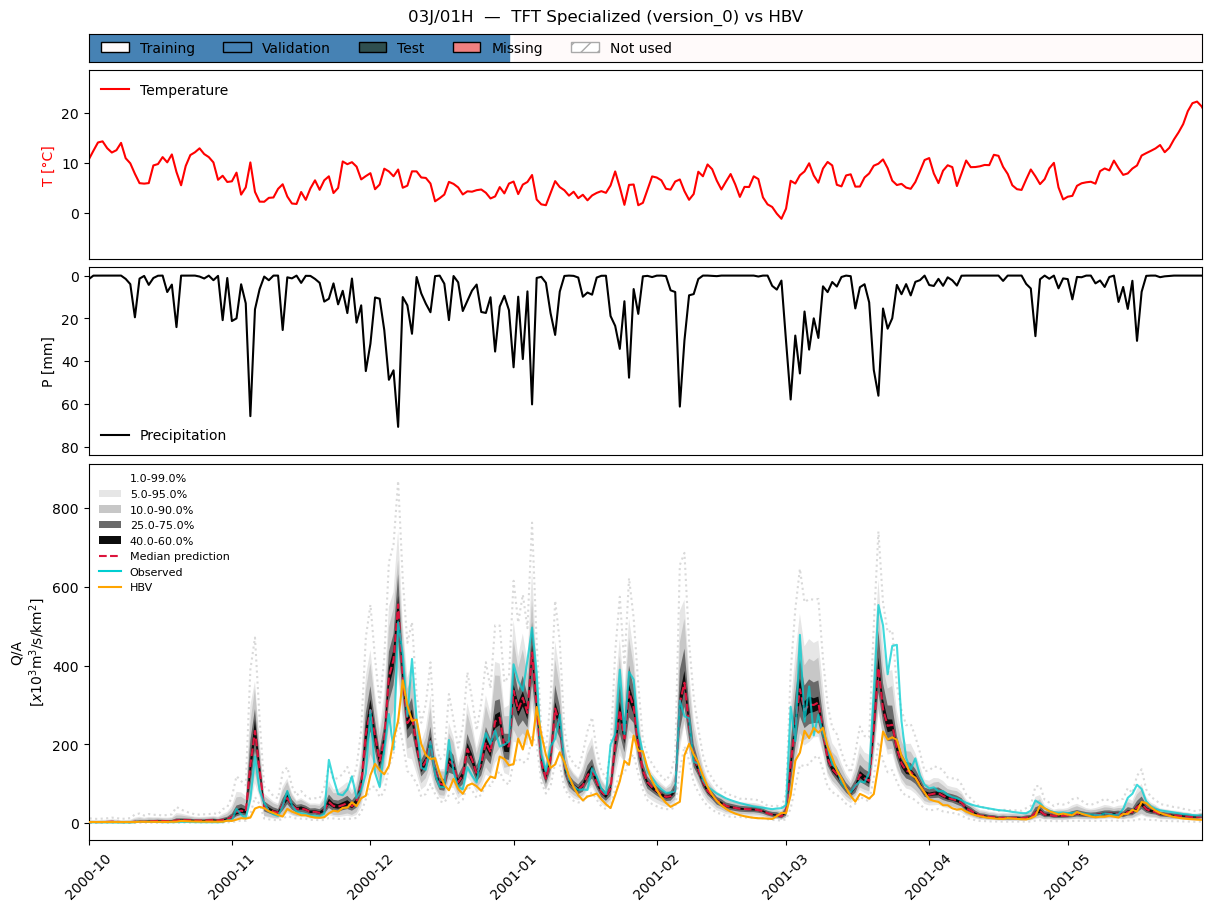

In [ ]:
# ── Load everything ────────────────────────────────────────────────────────────
prediction = load_prediction_csv(csv_path, GROUP)
data       = load_meteo_data(GROUP)
hbv_q      = load_hbv(GROUP)

# ── Build the figure with the plotting function ─────────────────────────────────
partial = (EXPERIMENT == "specialized")   # show 'Not used' hatch for retraining splits

fig, axes, forecast_legend = plot_prediction(
    prediction, data, GROUP, LEAD,
    temperature="t2m",
    precipitation="tp",
    target_label="Q/A\n[x10$^{3} m$^3$/s/km$^2$]",
    partial_retraining=partial,
)
ax_training, ax_temperature, ax_precipitation, ax_forecast = axes
leg_handles, leg_labels = forecast_legend

# ── Overlay HBV on the forecast panel ───────────────────────────────────────────
start = pd.Timestamp(DATE_START) if DATE_START else prediction.index.min()
end   = pd.Timestamp(DATE_END)   if DATE_END   else prediction.index.max()

hbv_available = hbv_q is not None and STATION in desc.index
if hbv_available:
    area = float(desc.loc[STATION, "area"])
    hbv_win = hbv_q.loc[start:end]
    ax_forecast.plot(
        hbv_win.index,
        hbv_win / area * 10 ** 3,     # normalise to specific streamflow Q/A x10^3
        color="orange", zorder=10,
    )
else:
    print("HBV simulation not available for this station.")

# ── Extend the existing forecast legend (quantile bands + median + observed) ────
# forecast_legend already contains the shaded-band rectangles and the median /
# observed line entries built inside plot_prediction. We only append HBV.
from matplotlib.lines import Line2D as _L
if hbv_available:
    leg_handles.append(_L([0], [0], color="orange", linestyle="-"))
    leg_labels.append("HBV")
ax_forecast.legend(leg_handles, leg_labels, fontsize=8, numpoints=1, loc=2, frameon=False)

# ── Cosmetic adjustments (mirrors the author's script) ──────────────────────────
for ax in axes:
    ax.set_xlim(start, end)
    ax.grid(False)
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=10)
    if ax is not ax_forecast:
        ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
        ax.set_xticks([])
        ax.set_xticks([], minor=True)S

fig.set_size_inches(12, 9)
title_kind = "Ungauged" if EXPERIMENT == "ungauged" else f"Specialized ({VERSION})"
fig.suptitle(f"{GROUP}  —  TFT {title_kind} vs HBV")

ax_temperature.set_ylabel("T [°C]", fontsize=10)
ax_precipitation.set_ylabel("P [mm]", fontsize=10)
ax_forecast.set_ylabel("Q/A\n[$x10^{3} $m$^3$/s/km$^2$]", fontsize=10)
ax_forecast.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax_forecast.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_forecast.xaxis.set_tick_params(rotation=45, labelsize=10)

if Y_LIMIT is not None:
    ax_forecast.set_ylim(*Y_LIMIT)

# ── Save ─────────────────────────────────────────────────────────────────────────
if SAVE:
    tag = "ungauged" if EXPERIMENT == "ungauged" else f"specialized_{VERSION}"
    out_path = OUT_DIR / f"{STATION}_{tag}_vs_HBV.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_path}")

plt.show()